In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [2]:
np.random.seed(42)
N = 2000

In [3]:
lux = np.random.uniform(50, 400, N)
time_of_day = np.random.uniform(0, 24, N)
curtain = np.random.choice([0,1], N)
occupancy = np.random.choice([0,1], N)

# Hidden True User Behavior (unknown to models)
effective = lux + 80*curtain - 2*(time_of_day - 12)**2
true_labels = ((occupancy == 1) & (effective < 250)).astype(int)

In [4]:
X = np.column_stack((lux, time_of_day, curtain, occupancy))
y = true_labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [5]:
def no_ai(lux_value):
    return 1 if lux_value < 200 else 0

pred_no_ai = np.array([no_ai(l) for l in X_test[:,0]])
acc_no_ai = accuracy_score(y_test, pred_no_ai)

In [ ]:
def rule_based_ai(l, t, c, o):
    if o == 1:
        if c == 0 and l < 220:
            return 1
        if c == 1 and l < 180:
            return 1
        if t > 18 and l < 250:
            return 1
    return 0

pred_ai = np.array([
    rule_based_ai(l, t, c, o)
    for l, t, c, o in zip(
        X_test[:,0], X_test[:,1], X_test[:,2], X_test[:,3]
    )
])

acc_ai = accuracy_score(y_test, pred_ai)

In [7]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred_ml = model.predict(X_test)
acc_ml = accuracy_score(y_test, pred_ml)

In [8]:
print("No AI Accuracy:", acc_no_ai)
print("Rule-Based AI Accuracy:", acc_ai)
print("ML Accuracy:", acc_ml)

No AI Accuracy: 0.6083333333333333
Rule-Based AI Accuracy: 0.8666666666666667
ML Accuracy: 0.9266666666666666


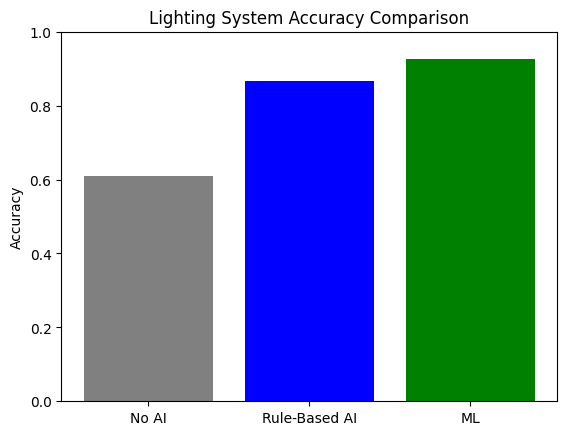

In [9]:
models = ["No AI", "Rule-Based AI", "ML"]
accuracies = [acc_no_ai, acc_ai, acc_ml]

colors = ["gray", "blue", "green"]

plt.figure()
plt.bar(models, accuracies, color=colors)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Lighting System Accuracy Comparison")

plt.show()